# Twiss parameters from transfer matrices

Starting from a transfer matrix ${\bf M}$

$$
{\bf M} = \begin{bmatrix}
            m_{11} & m_{12} \\
            m_{21} & m_{22} 
          \end{bmatrix}
$$

One could generate many particles ${\bf v}_i$ and see the effect of the transfer matrix, so 

$$ 
{\bf v}^{\prime}_i = {\bf M} {\bf v}_i
$$

with these ${\bf v}_i$ the emittance $\epsilon$, and Twiss functions $\alpha$, $\beta$ and $\gamma$ can be calculated using 
$$
\begin{eqnarray}
\epsilon & = & \sqrt{\left< x^2 \right> \left< x^{\prime 2}\right> - \left< x x^{\prime} \right>^2}  \\
\beta    & = & \frac{\left<x^2\right>}{\epsilon} \\
\gamma   & = & \frac{\left<x^{\prime2} \right>}{\epsilon} \\
\alpha   & = & - \frac{\left<x x^{\prime} \right>}{\epsilon}
\end{eqnarray}
$$

The sigma matrix after ${\bf M}$ is  

$$ 
\begin{eqnarray} 
{\bf \Sigma}_1  & = & {\bf M} {\bf \Sigma}_0 {\bf M}^{T} \\
                & = & \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix}
                      \begin{bmatrix} \sigma_{11} & \sigma_{12} \\ \sigma_{21} & \sigma_{22} \end{bmatrix} 
                      \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix} \\
                & = & \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix}
                      \epsilon \begin{bmatrix} \beta_0 & -\alpha_0 \\ -\alpha_0  & \gamma_0 \end{bmatrix} 
                      \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix} \\
\epsilon \begin{bmatrix} \beta_1 & -\alpha_1 \\ -\alpha_1  & \gamma_1 \end{bmatrix} & = & 
                      \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix}
                      \epsilon \begin{bmatrix} \beta_0 & -\alpha_0 \\ -\alpha_0  & \gamma_0 \end{bmatrix} 
                      \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix} \\
\begin{bmatrix} \beta_1 & -\alpha_1 \\ -\alpha_1  & \gamma_1 \end{bmatrix} & = &  
                      \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix}
                      \begin{bmatrix} 
                      m_{11} \beta_0 - m_{21} \alpha_0   & m_{12} \beta_0 - m_{22} \alpha_0 \\
                      -m_{11} \alpha_0 + m_{21} \gamma_0 & -m_{12} \alpha_0 + m_{22} \gamma_0 
                      \end{bmatrix} \\
                & = & {\rm TODO finish expansion}       
\end{eqnarray}  
$$

Finally gathering terms and writing as a 3x3 matrix

$$
\begin{bmatrix} \beta_1 \\ \alpha_1 \\ \gamma_1 \end{bmatrix} = 
\begin{bmatrix} 
m_{11}^2 & -2 m_{11} m_{12} & m_{12}^2 \\
-m_{11} m_{21} & 1 + 2 m_{12} m_{21} \ &  -m_{12} m_{22} \\
m_{21}^2 & -2 m_{21} m_{22} & m_{22}^2 \\
\end{bmatrix}
\begin{bmatrix} \beta_0 \\ \alpha_0 \\ \gamma_0 \end{bmatrix}
$$

So how does $\beta$, $\alpha$ and $\gamma$ evolve in a drift? A drift of length $L$ transfer matrix is 

$
{\bf M}_{\rm drift} = \begin{bmatrix} 
                        1 & L \\
                        0 & 1 
                      \end{bmatrix}
$

This gives the matrix elements $m_{ij}$. These can be used to propagate $(\beta, \alpha, \gamma)_0$ through the drift. So we can write a function that converts the transfer matrix to a Twiss propagation matrix

In [103]:
import numpy as np

def twiss_propagation(m) :
    '''
    :param m: Transfer matrix
    :type m: numpy.array 2x2
    :return: Twiss transfer
    :rtype: numpy.array 3x3 
    '''
    return np.array([[m[0,0]**2, -2*m[0,0]*m[0,1], m[0,1]**2],
                     [-m[0,0]*m[1,0], 1+ 2*m[0,1]*m[1,0], -m[0,1]*m[1,1]],
                     [m[1,0]**2, -2*m[1,0]*m[1,1], m[1,1]**2]])
    

mdrift = np.array([[1,0.1],[0,1]])
twiss_propagation(mdrift)

array([[ 1.  , -0.2 ,  0.01],
       [-0.  ,  1.  , -0.1 ],
       [ 0.  , -0.  ,  1.  ]])

We can make a function to plot the Twiss functions over a range of $s$ 

In [105]:
def gam(alp, bet) :
    '''
    Calculate gamma from alpha and beta
    '''
    return (1+alp**2)/bet

# starting parameters 
bet = 1 
alp = 0.75
t = (bet, alp, gam(bet,alp))

# lists to store output
slist = [] # list of s positions
tlist = [] # list of Twiss vectors 

ds = 0.05
mdrift = np.array([[1,ds],[0,1]])

for l in range(20) :
    slist.append(l)
    tlist.append(t)
    tpropagation = twiss_propagation(mdrift)
    t = tpropagation @ t

# convert to numpy arrays
sarray = np.array(slist) 
tarray = np.array(tlist) 

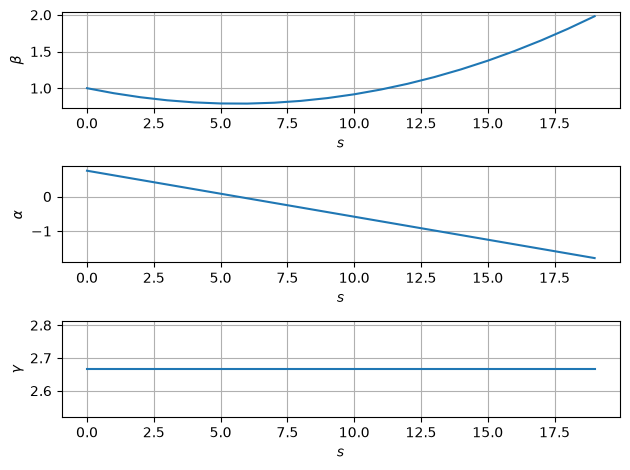

In [102]:
import matplotlib.pyplot as plt
plt.subplot(3,1,1)
plt.plot(sarray, tarray[:,0])
plt.xlabel('$s$')
plt.ylabel('$\\beta$')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(sarray, tarray[:,1])
plt.xlabel('$s$')
plt.ylabel('$\\alpha$')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(sarray, tarray[:,2])
plt.xlabel('$s$')
plt.ylabel('$\\gamma$')
plt.grid(True)

plt.tight_layout()